# Notebook 01 — Data Understanding

## Objective
Get familiar with the NASA battery dataset before touching any modeling code: how many files exist, what each experiment type (charge/discharge/impedance) looks like, and whether the metadata is clean.

## Why This Step Is Needed
Every later notebook depends on assumptions made here (folder structure, filename ordering, metadata columns). Checking these explicitly now prevents confusing bugs three notebooks later.

## Workflow Position
```
[YOU ARE HERE] -> 01 Data Understanding -> 02 Preprocessing -> 03 Feature Engineering
-> 04 Ground Truth Labels -> 05 Model Training (AHRF) -> 06 Model Comparison
-> 07 Explainability (SHAP) -> 08 Decision Engine & Summary
```


## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.core.config import ensure_dirs, BATTERY_IDS
from src.core.data_loader import load_metadata, parse_start_time
from src.preprocessing.cleaner import validate_processed_structure
from src.core.data_loader import load_processed_file, list_processed_files

ensure_dirs()
plt.rcParams["figure.figsize"] = (10, 5)


## 2. Validate Folder Structure

Before loading anything, confirm the `dataset/processed/<battery_id>/{charge,discharge,impedance}/` folders are actually populated. This function is designed to fail loudly and clearly here, rather than causing a confusing error in a later notebook.


In [3]:
validate_processed_structure()


Processed data structure check:
  B0005:
    charge       ->  170 files   [OK]
    discharge    ->  168 files   [OK]
    impedance    ->  278 files   [OK]

All expected folders contain data. Safe to proceed.


{'B0005': {'charge': 170, 'discharge': 168, 'impedance': 278}}

### Observation
Every experiment type should show `[OK]` above with a non-zero file count for each battery in `BATTERY_IDS`. If anything shows `[MISSING/EMPTY]`, stop here and fix the folder before continuing -- every notebook after this one assumes this check passes.


## 3. Load and Inspect Metadata

`load_metadata()` automatically cleans two known issues in this dataset: a duplicated header row embedded in the data, and the entire file being duplicated. It prints exactly what it cleaned.


In [4]:
metadata = load_metadata()
print("Metadata shape:", metadata.shape)
metadata.head()


load_metadata(): cleaned 7566 bad/duplicate rows (15131 -> 7565).
Metadata shape: (7565, 10)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.056058,0.200970
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.053192,0.164734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,NaN,NaN


In [5]:
metadata.info()


<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 7565 non-null   str    
 1   start_time           7565 non-null   str    
 2   ambient_temperature  7565 non-null   int64  
 3   battery_id           7565 non-null   str    
 4   test_id              7565 non-null   str    
 5   uid                  7565 non-null   str    
 6   filename             7565 non-null   str    
 7   Capacity             2769 non-null   float64
 8   Re                   1947 non-null   float64
 9   Rct                  1947 non-null   float64
dtypes: float64(3), int64(1), str(6)
memory usage: 591.1 KB


### Observation
Note the row count after cleaning, and confirm `ambient_temperature`, `Capacity`, `Re`, `Rct` show up as numeric (`float64`) dtypes, not `object` -- this confirms the cleaning in `load_metadata()` worked correctly.


## 4. How Many Batteries Are Available?

The metadata file contains more batteries than just the one this project currently uses (`BATTERY_IDS` in `config.py`). Useful to know for future extension, even though we stay scoped to `B0005` for this project.


In [6]:
battery_counts = metadata["battery_id"].value_counts()
print(f"Total distinct batteries in metadata: {metadata['battery_id'].nunique()}")
battery_counts.head(10)


Total distinct batteries in metadata: 34


battery_id
B0006    616
B0005    616
B0007    616
B0034    486
B0033    486
B0036    486
B0018    319
B0043    275
B0042    275
B0044    275
Name: count, dtype: int64

## 5. Experiment Type Distribution — Our Battery(s)


In [7]:
for battery_id in BATTERY_IDS:
    subset = metadata[metadata["battery_id"] == battery_id]
    print(f"\n{battery_id} experiment breakdown:")
    print(subset["type"].value_counts())



B0005 experiment breakdown:
type
impedance    278
charge       170
discharge    168
Name: count, dtype: int64


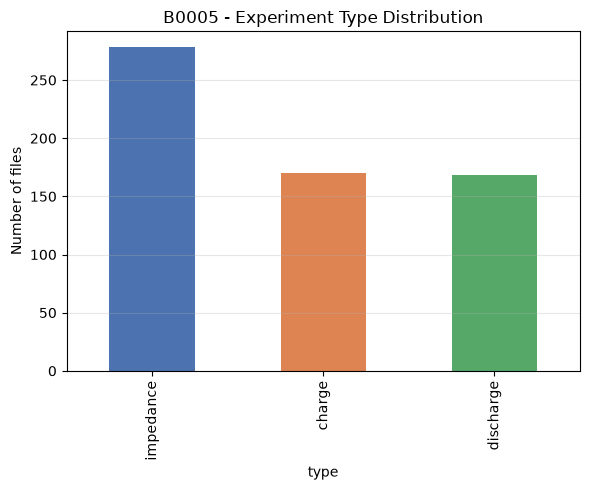

In [8]:
fig, axes = plt.subplots(1, len(BATTERY_IDS), figsize=(6 * len(BATTERY_IDS), 5))
if len(BATTERY_IDS) == 1:
    axes = [axes]

for ax, battery_id in zip(axes, BATTERY_IDS):
    subset = metadata[metadata["battery_id"] == battery_id]
    subset["type"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
    ax.set_title(f"{battery_id} - Experiment Type Distribution")
    ax.set_ylabel("Number of files")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### Observation
Discharge and charge cycles should be roughly balanced (each discharge cycle is typically followed by a charge cycle), with impedance cycles interspersed less frequently. A large imbalance would be worth investigating before proceeding.


## 6. Inspect One Raw Cycle File

Load a single discharge file to see the actual column names and a few rows of real sensor data. This confirms our assumed column names (`Voltage_measured`, `Current_measured`, etc., used throughout `src/feature_engineering/extractor.py`) actually match reality.


In [9]:
battery_id = BATTERY_IDS[0]
discharge_files = list_processed_files(battery_id, "discharge")
print(f"Number of discharge files: {len(discharge_files)}")
print("First 5 filenames:", discharge_files[:5])
print("Last 5 filenames:", discharge_files[-5:])

sample_df = load_processed_file(battery_id, "discharge", discharge_files[0])
sample_df.head()


Number of discharge files: 168
First 5 filenames: ['05122.csv', '05124.csv', '05126.csv', '05128.csv', '05130.csv']
Last 5 filenames: ['05720.csv', '05724.csv', '05728.csv', '05732.csv', '05734.csv']


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.191492,-0.004902,24.330034,-0.0006,0.000,0.000
1,4.190749,-0.001478,24.325993,-0.0006,4.206,16.781
2,3.974871,-2.012528,24.389085,-1.9982,3.062,35.703
3,3.951717,-2.013979,24.544752,-1.9982,3.030,53.781
4,3.934352,-2.011144,24.731385,-1.9982,3.011,71.922


In [10]:
sample_df.describe()


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,3.529829,-1.818702,32.572328,-1.805570,2.404944,1812.087497
std,0.236558,0.595058,3.495804,0.591217,0.796974,1069.272600
min,2.612467,-2.018015,24.325993,-1.998400,0.000000,0.000000
25%,3.418746,-2.013447,30.422589,-1.998200,2.498000,891.812000
50%,3.529903,-2.012427,32.865786,-1.998200,2.610000,1796.328000
75%,3.685214,-2.011144,35.095568,-1.998200,2.765000,2724.203000
max,4.191492,0.000729,38.982181,-0.000400,4.206000,3690.234000


### Observation
Check the column names printed above against `DEFAULT_SIGNAL_COLUMNS` in `src/feature_engineering/extractor.py`. If your actual column names differ (e.g. different capitalization or naming), update that list before running Notebook 03 -- it is the single place that needs to change.


## 7. Visualize a Single Discharge Cycle

A quick sanity-check plot: does the voltage curve look like a real battery discharge curve (starts high, drops, has a knee near the end)?


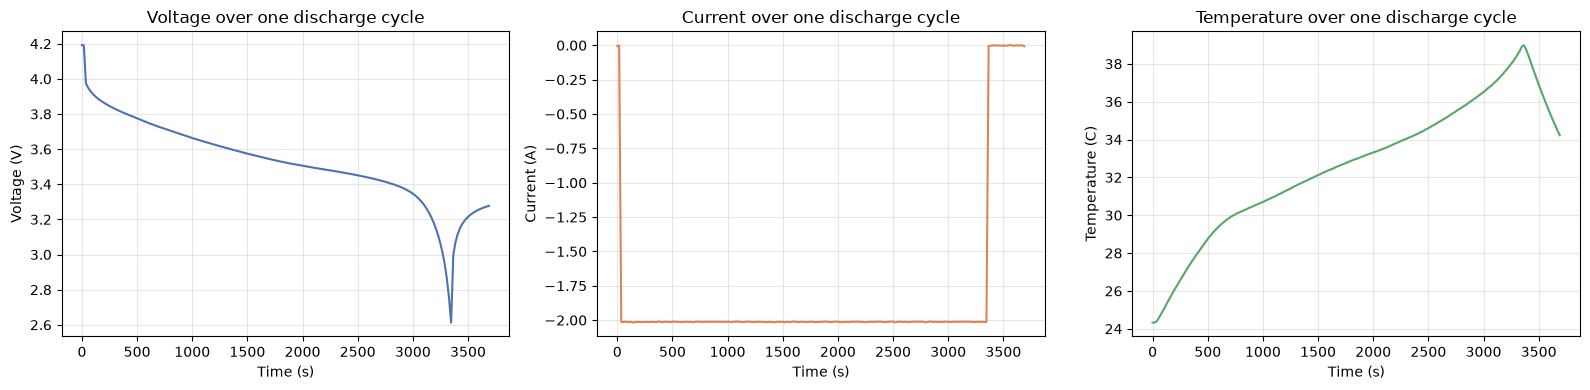

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if "Voltage_measured" in sample_df.columns:
    axes[0].plot(sample_df["Time"], sample_df["Voltage_measured"], color="#4C72B0")
    axes[0].set_title("Voltage over one discharge cycle")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Voltage (V)")

if "Current_measured" in sample_df.columns:
    axes[1].plot(sample_df["Time"], sample_df["Current_measured"], color="#DD8452")
    axes[1].set_title("Current over one discharge cycle")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Current (A)")

if "Temperature_measured" in sample_df.columns:
    axes[2].plot(sample_df["Time"], sample_df["Temperature_measured"], color="#55A868")
    axes[2].set_title("Temperature over one discharge cycle")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel("Temperature (C)")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Observation
The voltage curve should decrease over the cycle (battery discharging), current should stay roughly constant (constant-current discharge test), and temperature should rise slightly due to internal heating. If any of these look wrong (e.g. voltage increasing), double check the file was read correctly.


## 8. Verify Filename Order = True Chronological Order

Our feature extraction pipeline (Notebook 03) sorts cycle files by filename and treats that as cycle order. This check confirms that assumption is actually true for this battery, using the real recorded `start_time` from metadata.


In [12]:
battery_meta = metadata[(metadata["battery_id"] == battery_id) & (metadata["type"] == "discharge")].copy()
battery_meta["start_time_parsed"] = battery_meta["start_time"].apply(parse_start_time)

by_filename = battery_meta.sort_values("filename")
by_time = battery_meta.sort_values("start_time_parsed")

match_fraction = (by_filename["filename"].values == by_time["filename"].values).mean()
print(f"Fraction of discharge cycles where filename order == true chronological order: {match_fraction:.2%}")


Fraction of discharge cycles where filename order == true chronological order: 100.00%


### Observation
This should read 100% (or very close to it). If it's meaningfully below 100%, do NOT trust filename order for chronological splitting later -- switch to sorting by `parse_start_time(start_time)` instead throughout the pipeline.


## Results Summary

| Check | Result |
|---|---|
| Processed folder structure | See Section 2 output |
| Metadata rows after cleaning | See Section 3 output |
| Discharge / Charge / Impedance file counts | See Section 5 output |
| Column names match `extractor.py` assumptions | See Section 6 |
| Filename order == chronological order | See Section 8 output |

## Conclusion
This notebook confirmed the dataset is correctly organized, the metadata is clean (after automatic deduplication), the raw sensor columns match what the feature engineering pipeline expects, and filenames can be trusted as a proxy for cycle order.

## Next Steps
Notebook 02 will clean each individual cycle file (missing values, bad dtypes) and confirm the cleaning function works correctly on real data before feature extraction begins.
